In [13]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy.stats import spearmanr

_here = Path.cwd()
if not (_here / 'salary_analysis.ipynb').exists():
    for _c in [_here / 'priors',
               _here / 'premier_league' / 'priors',
               _here / 'non_penalty_bayes' / 'premier_league' / 'priors',
               _here / 'team_strength' / 'non_penalty_bayes' / 'premier_league' / 'priors']:
        if _c.exists():
            os.chdir(_c)
            break

NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT    = str(NOTEBOOK_DIR.parents[5])
OUT_DIR      = NOTEBOOK_DIR / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from salary_and_champ_regressions import (
    pl_team_season_goals, build_champ_panel, build_salary_panel,
)

# ── shared palette (one system, used consistently across every chart) ──────
C_XG        = '#2a78d6'   # xG series (categorical slot 1 / diverging "under" pole)
C_GOALS     = '#eb6834'   # goals series (categorical slot 2)
C_PRED      = '#1baf7a'   # predicted-as-its-own-series (categorical slot 3)
C_OVER      = '#e34948'   # over-prediction / positive bias / positive luck
C_UNDER     = '#2a78d6'   # under-prediction / negative bias / negative luck
C_GRID      = '#e1e0d9'
C_AXIS      = '#c3c2b7'
C_MUTED     = '#898781'
C_INK       = '#0b0b0b'
C_INK2      = '#52514e'

plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'axes.edgecolor': C_AXIS,
    'axes.labelcolor': C_INK,
    'text.color': C_INK,
    'xtick.color': C_INK2,
    'ytick.color': C_INK2,
    'axes.grid': True,
    'grid.color': C_GRID,
    'grid.linewidth': 0.8,
    'axes.axisbelow': True,
})

# ── pull in the salary / championship-form / PL-scoring panels ─────────────
raw = pd.read_csv(NOTEBOOK_DIR / 'raw_results.csv')
pl_goals = pl_team_season_goals(raw)

champ_perf = pd.read_csv(NOTEBOOK_DIR / 'champ_performance.csv')
champ_panel = build_champ_panel(champ_perf, pl_goals)

salaries = pd.read_csv(NOTEBOOK_DIR / 'prem_salaries_adjusted.csv')
salary_panel = build_salary_panel(salaries, pl_goals)

print(f'pl_goals:     {len(pl_goals)} team-seasons')
print(f'champ_panel:  {len(champ_panel)} rows')
print(f'salary_panel: {len(salary_panel)} rows')
salary_panel.head()

pl_goals:     664 team-seasons
champ_panel:  27 rows
salary_panel: 220 rows


,team,season,gross_2025_26_terms,log_wage,gf_rate,ga_rate
0,Man City,2015-2016,177926810,18.996883,1.868421,1.078947
1,Man United,2015-2016,172603015,18.966505,1.289474,0.921053
2,Chelsea,2015-2016,140099850,18.757866,1.552632,1.394737
3,Arsenal,2015-2016,135476555,18.724309,1.710526,0.947368
4,Liverpool,2015-2016,131133460,18.691726,1.657895,1.315789


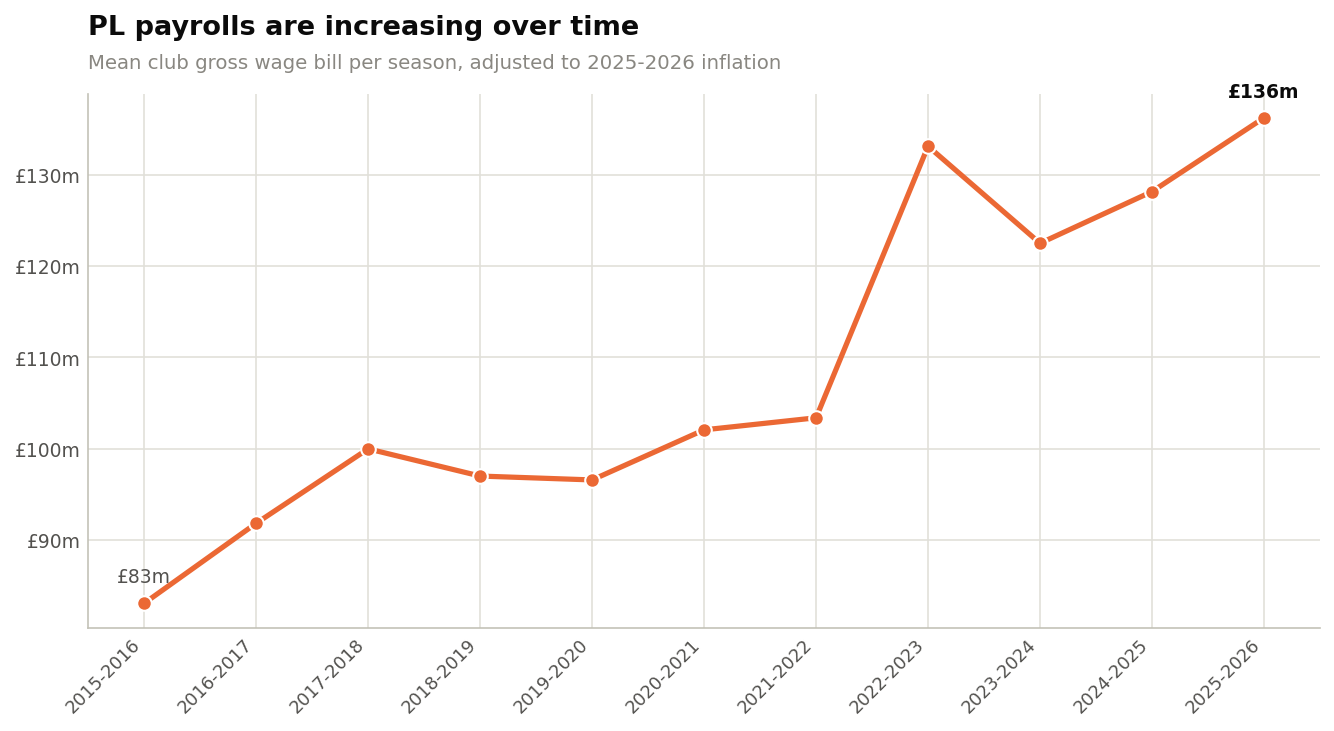

In [14]:
import matplotlib.ticker as ticker

avg_by_season = (
    salaries.groupby('season')['gross_2025_26_terms']
    .mean()
    .reindex(sorted(salaries['season'].unique()))
)

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

x = np.arange(len(avg_by_season))
y = avg_by_season.values / 1e6

ax.plot(x, y, color=C_GOALS, linewidth=2.5, marker='o', markersize=7,
        markerfacecolor=C_GOALS, markeredgecolor='white', markeredgewidth=1, zorder=3)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color(C_AXIS)
ax.spines['bottom'].set_color(C_AXIS)
ax.tick_params(length=0, colors=C_INK2)
ax.grid(axis='y', color=C_GRID, linewidth=0.8)
ax.set_axisbelow(True)

ax.set_xticks(x)
ax.set_xticklabels(avg_by_season.index, rotation=45, ha='right', fontsize=8.5)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'£{v:.0f}m'))
ax.tick_params(axis='y', labelsize=9)

# selective direct labels — endpoints only
ax.annotate(f'£{y[0]:.0f}m', (x[0], y[0]), textcoords='offset points',
            xytext=(0, 10), ha='center', fontsize=9, color=C_INK2)
ax.annotate(f'£{y[-1]:.0f}m', (x[-1], y[-1]), textcoords='offset points',
            xytext=(0, 10), ha='center', fontsize=9, fontweight='bold', color=C_INK)

ax.text(0, 1.1, 'PL payrolls are increasing over time', transform=ax.transAxes,
        fontsize=13, fontweight='bold', color=C_INK, va='bottom', ha='left')
ax.text(0, 1.04, 'Mean club gross wage bill per season, adjusted to 2025-2026 inflation',
        transform=ax.transAxes, fontsize=9.5, color=C_MUTED, va='bottom', ha='left')

plt.tight_layout()
fig.subplots_adjust(top=0.86)
plt.savefig(OUT_DIR / 'avg_wage_bill_by_season.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

In [15]:
# A chart showing how the wage bills in the Premier League have changed over time.

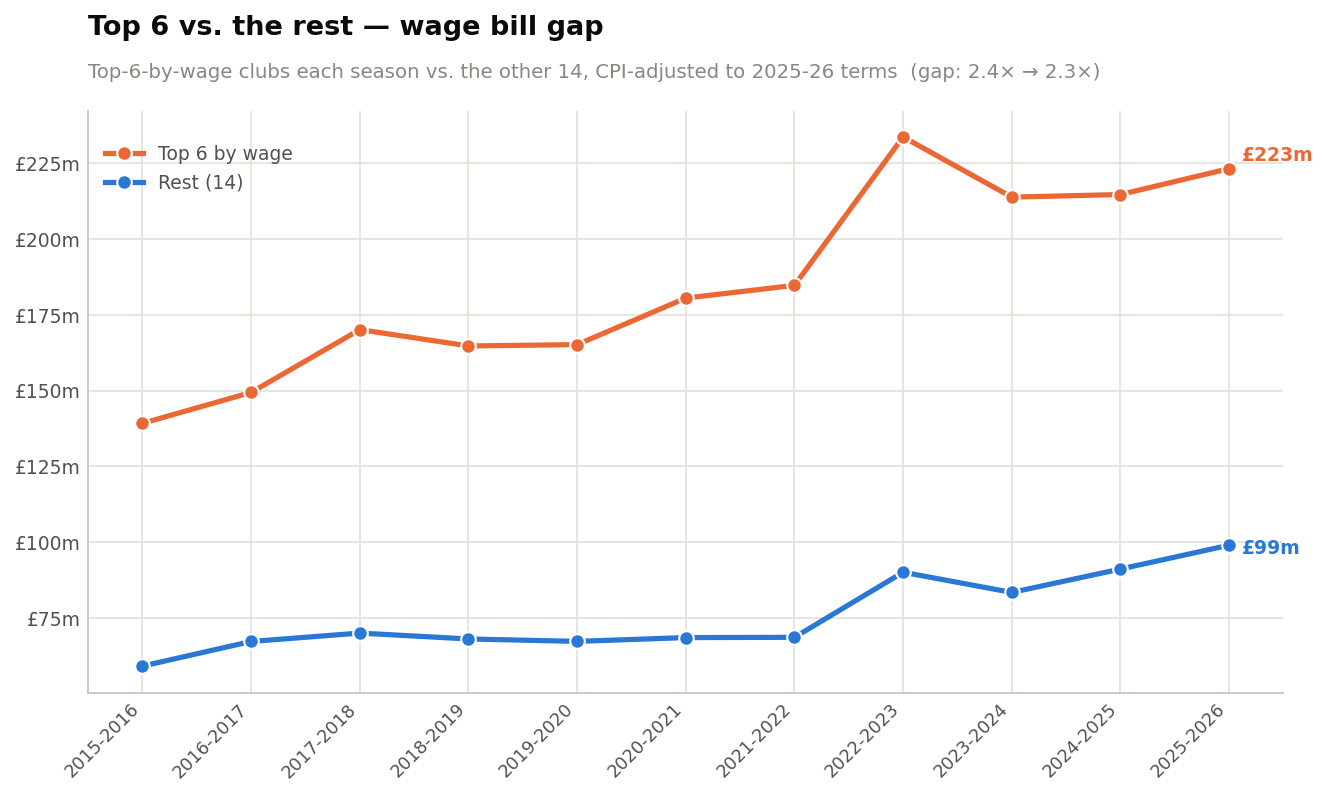

In [16]:
def _tier_means(g, n=6):
    s = g.sort_values('gross_2025_26_terms', ascending=False)
    return pd.Series({
        'top_avg': s.iloc[:n]['gross_2025_26_terms'].mean(),
        'rest_avg': s.iloc[n:]['gross_2025_26_terms'].mean(),
    })

tiers = (salaries.groupby('season', group_keys=False)
         .apply(_tier_means, include_groups=False)
         .reindex(sorted(salaries['season'].unique())))

x = np.arange(len(tiers))
y_top = tiers['top_avg'].values / 1e6
y_rest = tiers['rest_avg'].values / 1e6

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.plot(x, y_top, color=C_GOALS, linewidth=2.5, marker='o', markersize=7,
        markerfacecolor=C_GOALS, markeredgecolor='white', markeredgewidth=1,
        zorder=3, label='Top 6 by wage')
ax.plot(x, y_rest, color=C_XG, linewidth=2.5, marker='o', markersize=7,
        markerfacecolor=C_XG, markeredgecolor='white', markeredgewidth=1,
        zorder=3, label='Rest (14)')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color(C_AXIS)
ax.spines['bottom'].set_color(C_AXIS)
ax.tick_params(length=0, colors=C_INK2)
ax.grid(axis='y', color=C_GRID, linewidth=0.8)
ax.set_axisbelow(True)

ax.set_xticks(x)
ax.set_xticklabels(tiers.index, rotation=45, ha='right', fontsize=8.5)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'£{v:.0f}m'))
ax.tick_params(axis='y', labelsize=9)

ax.annotate(f'£{y_top[-1]:.0f}m', (x[-1], y_top[-1]), textcoords='offset points',
            xytext=(6, 4), ha='left', fontsize=9, fontweight='bold', color=C_GOALS)
ax.annotate(f'£{y_rest[-1]:.0f}m', (x[-1], y_rest[-1]), textcoords='offset points',
            xytext=(6, -4), ha='left', fontsize=9, fontweight='bold', color=C_XG)

gap_start = y_top[0] / y_rest[0]
gap_end = y_top[-1] / y_rest[-1]

ax.text(0, 1.12, 'Top 6 vs. the rest — wage bill gap', transform=ax.transAxes,
        fontsize=13, fontweight='bold', color=C_INK, va='bottom', ha='left')
ax.text(0, 1.05,
        f'Top-6-by-wage clubs each season vs. the other 14, CPI-adjusted to 2025-26 terms  '
        f'(gap: {gap_start:.1f}× → {gap_end:.1f}×)',
        transform=ax.transAxes, fontsize=9.5, color=C_MUTED, va='bottom', ha='left')

ax.legend(loc='upper left', bbox_to_anchor=(0, 0.97), frameon=False, fontsize=9, labelcolor=C_INK2)

plt.tight_layout()
fig.subplots_adjust(top=0.84)
plt.savefig(OUT_DIR / 'top6_vs_rest_wage_bill.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

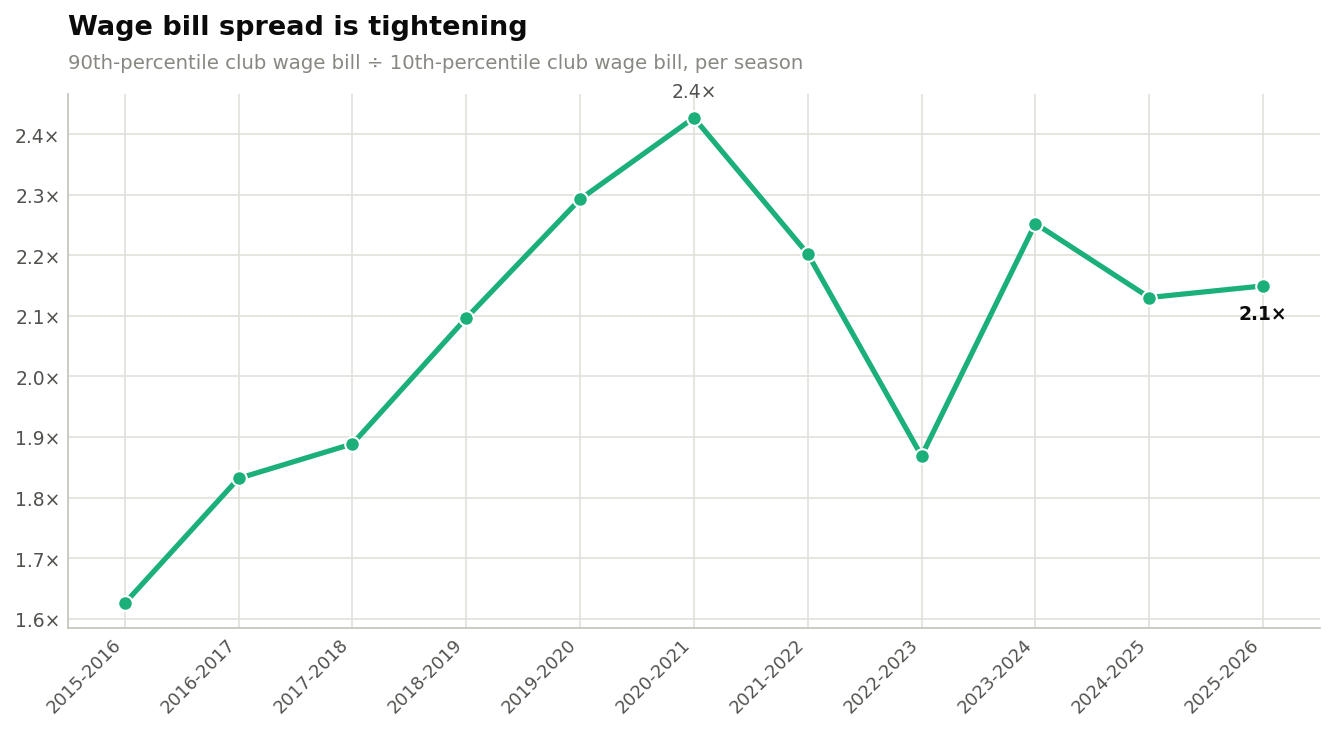

In [17]:
g = salaries.groupby('season')['gross_2025_26_terms']
spread = (g.quantile(.75) / g.quantile(.25)).reindex(sorted(salaries['season'].unique()))

x = np.arange(len(spread))
y = spread.values

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.plot(x, y, color=C_PRED, linewidth=2.5, marker='o', markersize=7,
        markerfacecolor=C_PRED, markeredgecolor='white', markeredgewidth=1, zorder=3)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color(C_AXIS)
ax.spines['bottom'].set_color(C_AXIS)
ax.tick_params(length=0, colors=C_INK2)
ax.grid(axis='y', color=C_GRID, linewidth=0.8)
ax.set_axisbelow(True)

ax.set_xticks(x)
ax.set_xticklabels(spread.index, rotation=45, ha='right', fontsize=8.5)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v:.1f}×'))
ax.tick_params(axis='y', labelsize=9)

peak_i = int(np.argmax(y))
ax.annotate(f'{y[peak_i]:.1f}×', (x[peak_i], y[peak_i]), textcoords='offset points',
            xytext=(0, 10), ha='center', fontsize=9, color=C_INK2)
ax.annotate(f'{y[-1]:.1f}×', (x[-1], y[-1]), textcoords='offset points',
            xytext=(0, -16), ha='center', fontsize=9, fontweight='bold', color=C_INK)

ax.text(0, 1.1, 'Wage bill spread is tightening', transform=ax.transAxes,
        fontsize=13, fontweight='bold', color=C_INK, va='bottom', ha='left')
ax.text(0, 1.04, '90th-percentile club wage bill ÷ 10th-percentile club wage bill, per season',
        transform=ax.transAxes, fontsize=9.5, color=C_MUTED, va='bottom', ha='left')

plt.tight_layout()
fig.subplots_adjust(top=0.86)
plt.savefig(OUT_DIR / 'wage_bill_spread_index.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

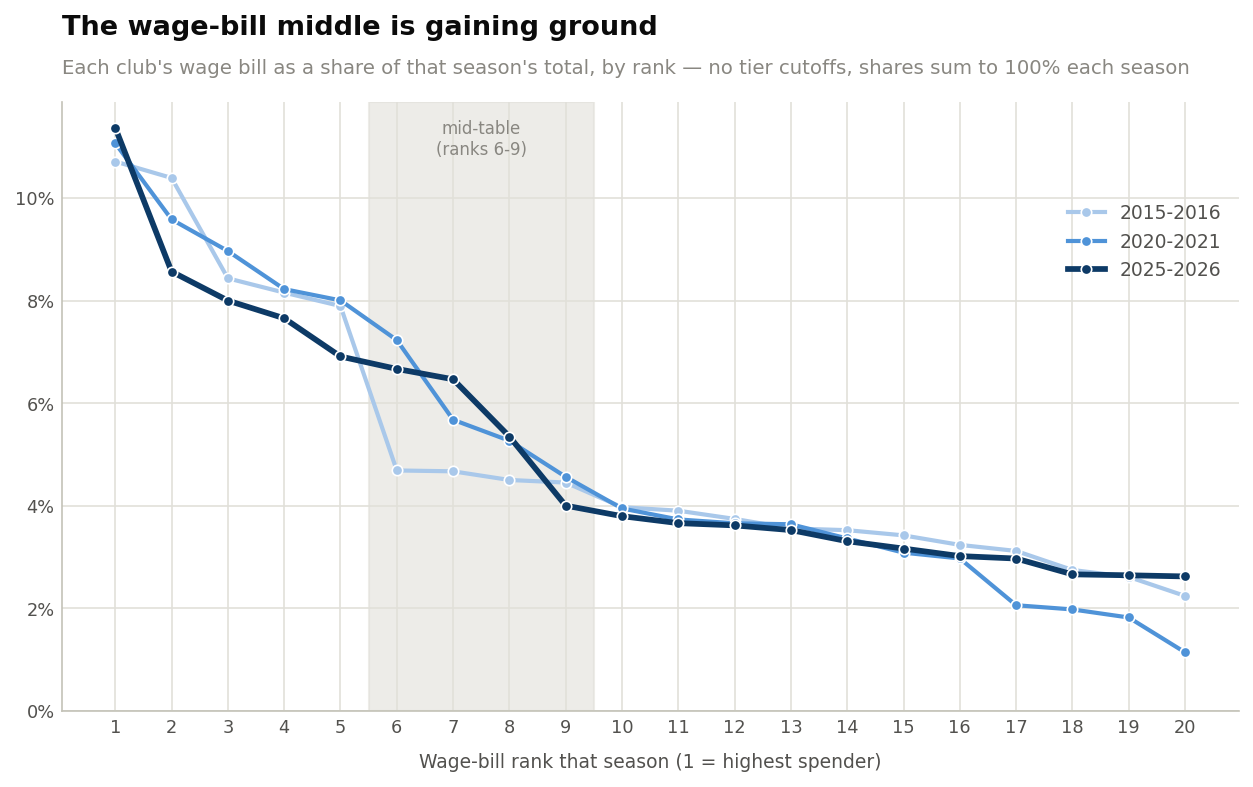

In [18]:
def _ranked_share(g):
    s = g.sort_values('gross_2025_26_terms', ascending=False).reset_index(drop=True)
    return pd.Series(
        (s['gross_2025_26_terms'] / s['gross_2025_26_terms'].sum() * 100).values,
        index=np.arange(1, len(s) + 1),
    )

snapshots = ['2015-2016', '2020-2021', '2025-2026']
# sequential single-hue ramp, light -> dark (oldest -> most recent) — time is
# ordinal here, not categorical, so one hue by lightness rather than 3 hues
ramp = {'2015-2016': '#a9c8ea', '2020-2021': '#4f93d8', '2025-2026': '#0d3a66'}
lw   = {'2015-2016': 2.0, '2020-2021': 2.0, '2025-2026': 2.75}

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for s in snapshots:
    curve = _ranked_share(salaries[salaries['season'] == s])
    ax.plot(curve.index, curve.values, color=ramp[s], linewidth=lw[s],
             marker='o', markersize=5, markerfacecolor=ramp[s],
             markeredgecolor='white', markeredgewidth=0.8, zorder=3, label=s)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color(C_AXIS)
ax.spines['bottom'].set_color(C_AXIS)
ax.tick_params(length=0, colors=C_INK2)
ax.grid(axis='y', color=C_GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.set_ylim(bottom=0)

ax.set_xticks(range(1, 21))
ax.set_xlabel('Wage-bill rank that season (1 = highest spender)', fontsize=9, color=C_INK2, labelpad=8)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.tick_params(axis='both', labelsize=8.5)

ax.axvspan(5.5, 9.5, color=C_GRID, alpha=0.6, zorder=0)
ymax = ax.get_ylim()[1]
ax.text(7.5, ymax * 0.97, 'mid-table\n(ranks 6-9)', ha='center', va='top',
        fontsize=8, color=C_MUTED)

ax.text(0, 1.1, 'The wage-bill middle is gaining ground', transform=ax.transAxes,
        fontsize=13, fontweight='bold', color=C_INK, va='bottom', ha='left')
ax.text(0, 1.04,
        "Each club's wage bill as a share of that season's total, by rank — "
        "no tier cutoffs, shares sum to 100% each season",
        transform=ax.transAxes, fontsize=9.5, color=C_MUTED, va='bottom', ha='left')

ax.legend(loc='upper right', bbox_to_anchor=(1, 0.86), frameon=False, fontsize=9, labelcolor=C_INK2)

plt.tight_layout()
fig.subplots_adjust(top=0.84)
plt.savefig(OUT_DIR / 'wage_share_by_rank.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

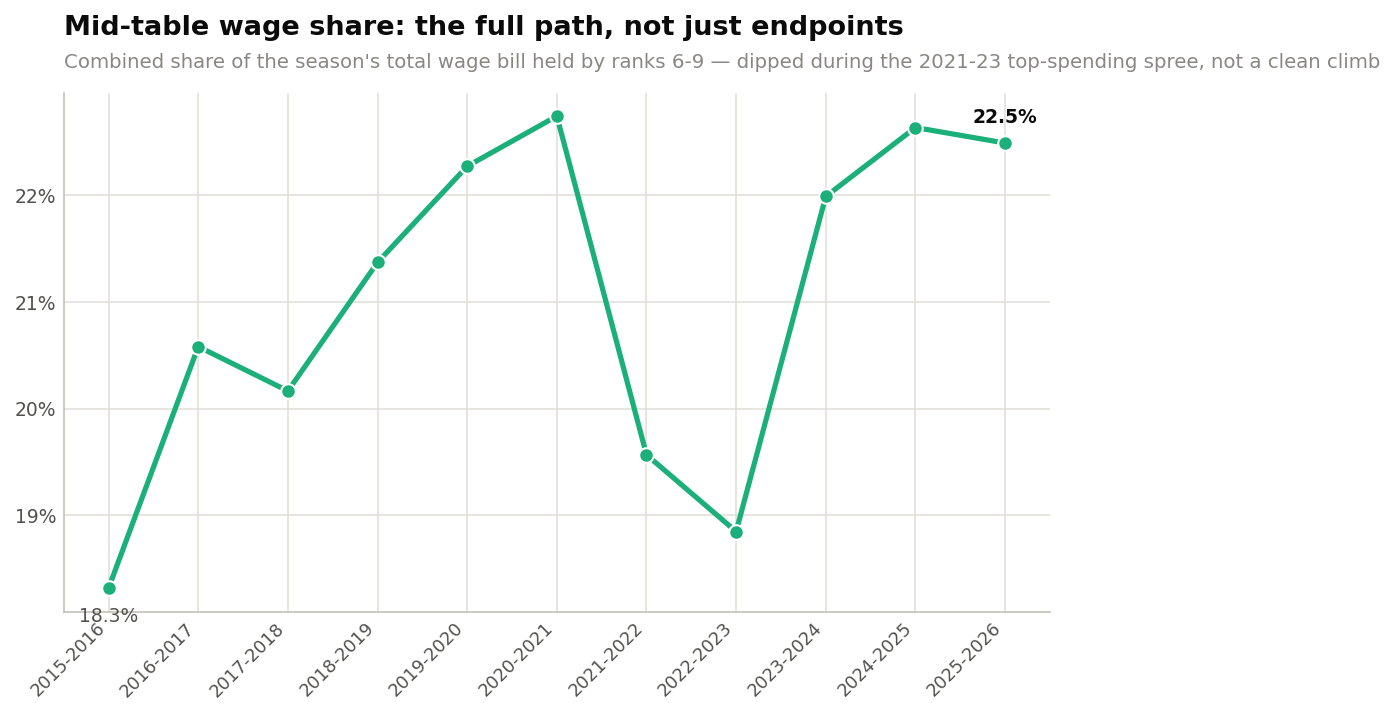

In [19]:
def _mid_share(g):
    s = g.sort_values('gross_2025_26_terms', ascending=False).reset_index(drop=True)
    shares = s['gross_2025_26_terms'] / s['gross_2025_26_terms'].sum() * 100
    return shares.iloc[5:9].sum()   # ranks 6-9 (0-indexed 5:9)

seasons = sorted(salaries['season'].unique())
mid = salaries.groupby('season', group_keys=False).apply(_mid_share, include_groups=False).reindex(seasons)

x = np.arange(len(mid))
y = mid.values

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.plot(x, y, color=C_PRED, linewidth=2.5, marker='o', markersize=7,
        markerfacecolor=C_PRED, markeredgecolor='white', markeredgewidth=1, zorder=3)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color(C_AXIS)
ax.spines['bottom'].set_color(C_AXIS)
ax.tick_params(length=0, colors=C_INK2)
ax.grid(axis='y', color=C_GRID, linewidth=0.8)
ax.set_axisbelow(True)

ax.set_xticks(x)
ax.set_xticklabels(mid.index, rotation=45, ha='right', fontsize=8.5)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.tick_params(axis='y', labelsize=9)

ax.annotate(f'{y[0]:.1f}%', (x[0], y[0]), textcoords='offset points',
            xytext=(0, -16), ha='center', fontsize=9, color=C_INK2)
ax.annotate(f'{y[-1]:.1f}%', (x[-1], y[-1]), textcoords='offset points',
            xytext=(0, 10), ha='center', fontsize=9, fontweight='bold', color=C_INK)

ax.text(0, 1.1, 'Mid-table wage share: the full path, not just endpoints', transform=ax.transAxes,
        fontsize=13, fontweight='bold', color=C_INK, va='bottom', ha='left')
ax.text(0, 1.04,
        "Combined share of the season's total wage bill held by ranks 6-9 — dipped during "
        "the 2021-23 top-spending spree, not a clean climb",
        transform=ax.transAxes, fontsize=9.5, color=C_MUTED, va='bottom', ha='left')

plt.tight_layout()
fig.subplots_adjust(top=0.84)
plt.savefig(OUT_DIR / 'mid_table_share_over_time.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

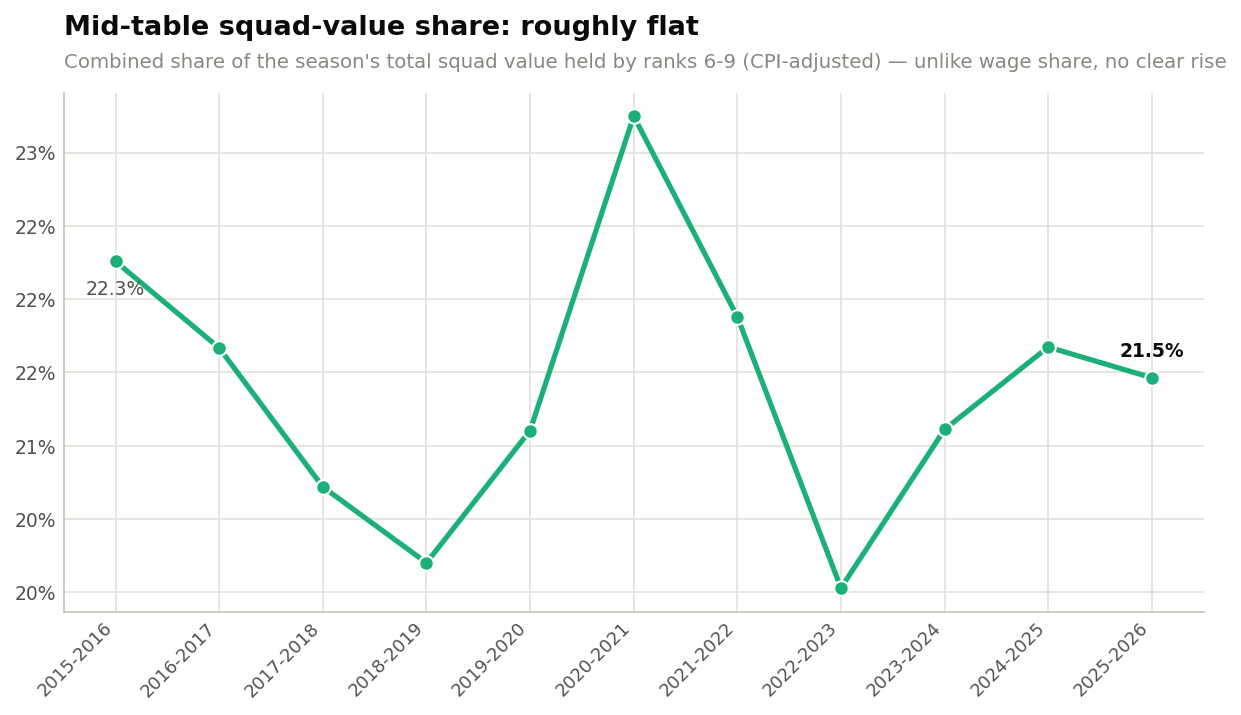

In [20]:
values = pd.read_csv(NOTEBOOK_DIR / 'transfermarkt_squad_values_adjusted.csv')

def _mid_share_value(g):
    s = g.sort_values('squad_value_2025_26_terms', ascending=False).reset_index(drop=True)
    shares = s['squad_value_2025_26_terms'] / s['squad_value_2025_26_terms'].sum() * 100
    return shares.iloc[5:9].sum()

seasons_v = sorted(values['season'].unique())
mid_v = values.groupby('season', group_keys=False).apply(_mid_share_value, include_groups=False).reindex(seasons_v)

x = np.arange(len(mid_v))
y = mid_v.values

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.plot(x, y, color=C_PRED, linewidth=2.5, marker='o', markersize=7,
        markerfacecolor=C_PRED, markeredgecolor='white', markeredgewidth=1, zorder=3)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color(C_AXIS)
ax.spines['bottom'].set_color(C_AXIS)
ax.tick_params(length=0, colors=C_INK2)
ax.grid(axis='y', color=C_GRID, linewidth=0.8)
ax.set_axisbelow(True)

ax.set_xticks(x)
ax.set_xticklabels(mid_v.index, rotation=45, ha='right', fontsize=8.5)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.tick_params(axis='y', labelsize=9)

ax.annotate(f'{y[0]:.1f}%', (x[0], y[0]), textcoords='offset points',
            xytext=(0, -16), ha='center', fontsize=9, color=C_INK2)
ax.annotate(f'{y[-1]:.1f}%', (x[-1], y[-1]), textcoords='offset points',
            xytext=(0, 10), ha='center', fontsize=9, fontweight='bold', color=C_INK)

ax.text(0, 1.1, 'Mid-table squad-value share: roughly flat', transform=ax.transAxes,
        fontsize=13, fontweight='bold', color=C_INK, va='bottom', ha='left')
ax.text(0, 1.04,
        "Combined share of the season's total squad value held by ranks 6-9 (CPI-adjusted) "
        "— unlike wage share, no clear rise",
        transform=ax.transAxes, fontsize=9.5, color=C_MUTED, va='bottom', ha='left')

plt.tight_layout()
fig.subplots_adjust(top=0.84)
plt.savefig(OUT_DIR / 'mid_table_value_share_over_time.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

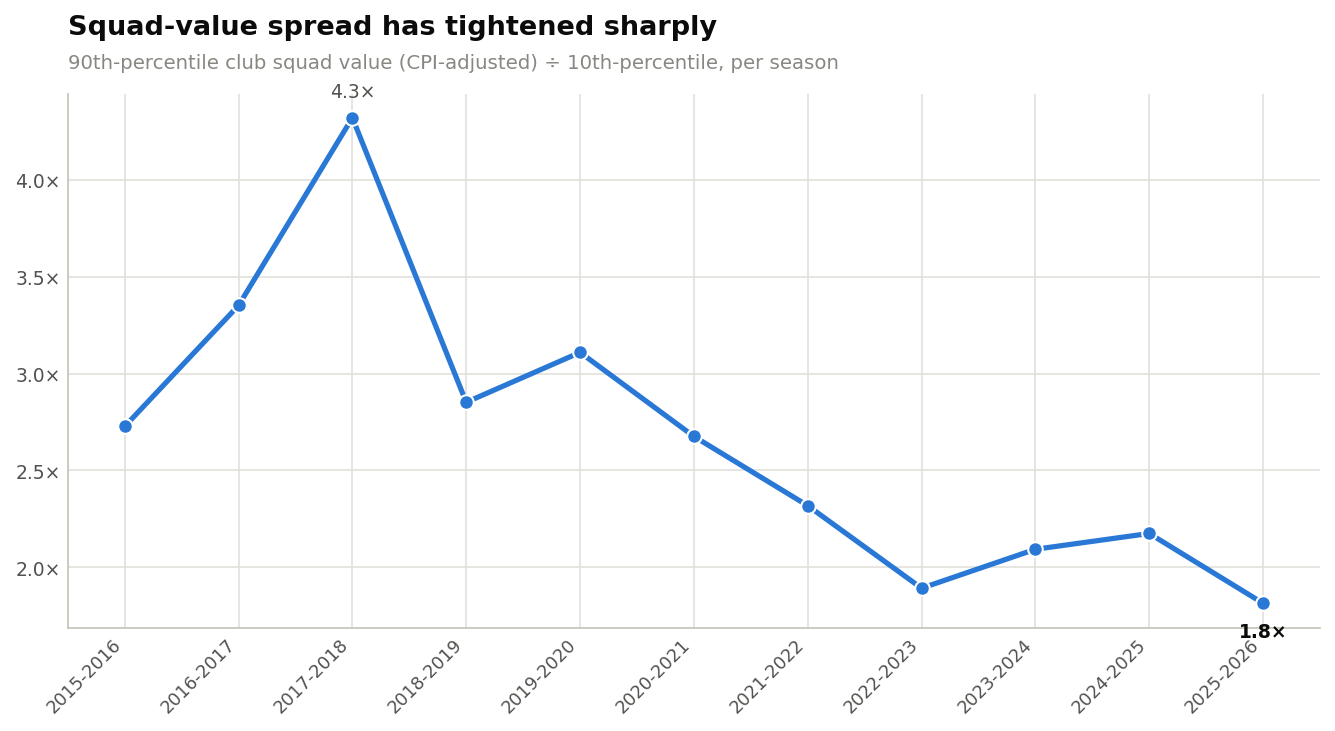

In [21]:
g = values.groupby('season')['squad_value_2025_26_terms']
spread_v = (g.quantile(.75) / g.quantile(.25)).reindex(seasons_v)

x = np.arange(len(spread_v))
y = spread_v.values

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.plot(x, y, color=C_XG, linewidth=2.5, marker='o', markersize=7,
        markerfacecolor=C_XG, markeredgecolor='white', markeredgewidth=1, zorder=3)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color(C_AXIS)
ax.spines['bottom'].set_color(C_AXIS)
ax.tick_params(length=0, colors=C_INK2)
ax.grid(axis='y', color=C_GRID, linewidth=0.8)
ax.set_axisbelow(True)

ax.set_xticks(x)
ax.set_xticklabels(spread_v.index, rotation=45, ha='right', fontsize=8.5)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v:.1f}×'))
ax.tick_params(axis='y', labelsize=9)

peak_i = int(np.argmax(y))
ax.annotate(f'{y[peak_i]:.1f}×', (x[peak_i], y[peak_i]), textcoords='offset points',
            xytext=(0, 10), ha='center', fontsize=9, color=C_INK2)
ax.annotate(f'{y[-1]:.1f}×', (x[-1], y[-1]), textcoords='offset points',
            xytext=(0, -16), ha='center', fontsize=9, fontweight='bold', color=C_INK)

ax.text(0, 1.1, 'Squad-value spread has tightened sharply', transform=ax.transAxes,
        fontsize=13, fontweight='bold', color=C_INK, va='bottom', ha='left')
ax.text(0, 1.04, '90th-percentile club squad value (CPI-adjusted) ÷ 10th-percentile, per season',
        transform=ax.transAxes, fontsize=9.5, color=C_MUTED, va='bottom', ha='left')

plt.tight_layout()
fig.subplots_adjust(top=0.86)
plt.savefig(OUT_DIR / 'squad_value_spread_index.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

In [22]:
from salary_and_champ_regressions import build_value_panel, fit_ols

value_panel = build_value_panel(values, pl_goals)
print(f'value_panel: {len(value_panel)} rows')
value_panel.head()

value_panel: 220 rows


,team,season,squad_value_2025_26_terms,log_value,gf_rate,ga_rate
0,Arsenal,2015-2016,641447164,20.279237,1.710526,0.947368
1,Arsenal,2016-2017,746520271,20.430933,2.026316,1.157895
2,Arsenal,2017-2018,929950721,20.650642,1.947368,1.342105
3,Arsenal,2018-2019,864621837,20.577803,1.921053,1.342105
4,Arsenal,2019-2020,786090462,20.482582,1.473684,1.263158


In [23]:
# 4 regressions: {wage bill, squad value} x {goals scored/game, goals conceded/game}
# both predictors CPI-adjusted, log-transformed (spending spans orders of magnitude,
# marginal returns taper off)
wage_attack   = fit_ols(salary_panel, ['log_wage'],  'gf_rate', 'WAGE BILL ATTACK')
wage_defense  = fit_ols(salary_panel, ['log_wage'],  'ga_rate', 'WAGE BILL DEFENSE')
value_attack  = fit_ols(value_panel,  ['log_value'], 'gf_rate', 'SQUAD VALUE ATTACK')
value_defense = fit_ols(value_panel,  ['log_value'], 'ga_rate', 'SQUAD VALUE DEFENSE')


WAGE BILL ATTACK: gf_rate ~ log_wage
  n=220, R^2=0.448
         const: -8.7987  (se=0.7676, p=0.000)
      log_wage:  0.5563  (se=0.0418, p=0.000)

WAGE BILL DEFENSE: ga_rate ~ log_wage
  n=220, R^2=0.281
         const:  7.8402  (se=0.6966, p=0.000)
      log_wage: -0.3503  (se=0.0379, p=0.000)

SQUAD VALUE ATTACK: gf_rate ~ log_value
  n=220, R^2=0.580
         const: -9.5503  (se=0.6327, p=0.000)
     log_value:  0.5495  (se=0.0317, p=0.000)

SQUAD VALUE DEFENSE: ga_rate ~ log_value
  n=220, R^2=0.364
         const:  8.3146  (se=0.6188, p=0.000)
     log_value: -0.3461  (se=0.0310, p=0.000)


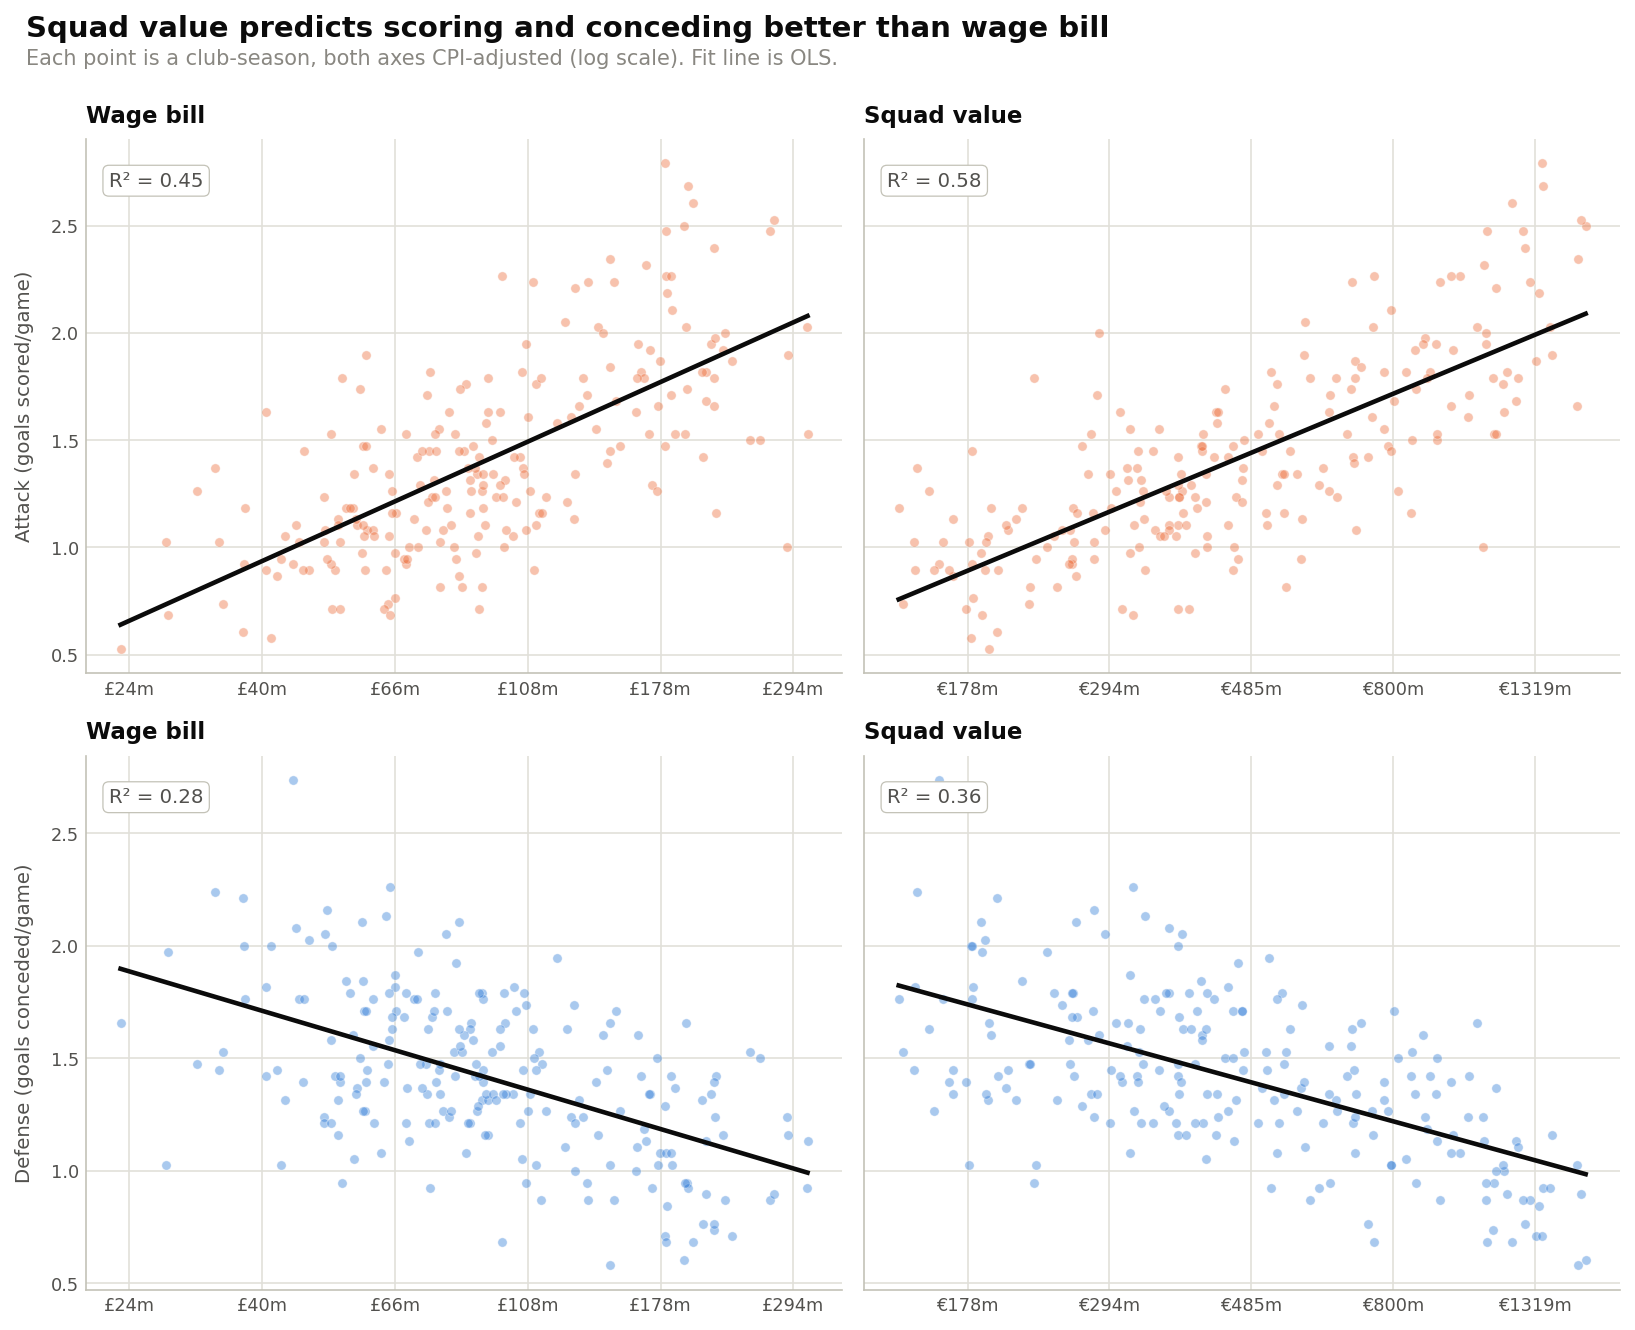

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharey='row')
fig.patch.set_facecolor('white')

panels = [
    (axes[0, 0], salary_panel, 'log_wage',  'gf_rate', wage_attack,   'Wage bill',   C_GOALS, '£'),
    (axes[0, 1], value_panel,  'log_value', 'gf_rate', value_attack,  'Squad value', C_GOALS, '€'),
    (axes[1, 0], salary_panel, 'log_wage',  'ga_rate', wage_defense,  'Wage bill',   C_XG,    '£'),
    (axes[1, 1], value_panel,  'log_value', 'ga_rate', value_defense, 'Squad value', C_XG,    '€'),
]

for ax, df, xcol, ycol, model, col_label, color, sym in panels:
    x = df[xcol].values
    y = df[ycol].values
    ax.scatter(x, y, s=20, color=color, alpha=0.4, edgecolor='white', linewidth=0.4, zorder=2)
    xs = np.linspace(x.min(), x.max(), 100)
    ys = model.params['const'] + model.params[xcol] * xs
    ax.plot(xs, ys, color=C_INK, linewidth=2.2, zorder=3)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color(C_AXIS)
    ax.spines['bottom'].set_color(C_AXIS)
    ax.tick_params(length=0, colors=C_INK2, labelsize=8.5)
    ax.grid(color=C_GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _, s=sym: f'{s}{np.exp(v)/1e6:.0f}m'))

    ax.set_title(col_label, fontsize=11, fontweight='bold', color=C_INK, loc='left', pad=8)
    ax.text(0.03, 0.94, f'R² = {model.rsquared:.2f}', transform=ax.transAxes,
            fontsize=9.5, color=C_INK2, va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=C_AXIS, linewidth=0.6))

axes[0, 0].set_ylabel('Attack (goals scored/game)', fontsize=9.5, color=C_INK2, labelpad=8)
axes[1, 0].set_ylabel('Defense (goals conceded/game)', fontsize=9.5, color=C_INK2, labelpad=8)

fig.text(0.02, 0.98, 'Squad value predicts scoring and conceding better than wage bill',
          fontsize=14, fontweight='bold', color=C_INK, va='top', ha='left')
fig.text(0.02, 0.955, 'Each point is a club-season, both axes CPI-adjusted (log scale). Fit line is OLS.',
          fontsize=10, color=C_MUTED, va='top', ha='left')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(OUT_DIR / 'wage_vs_value_regressions.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

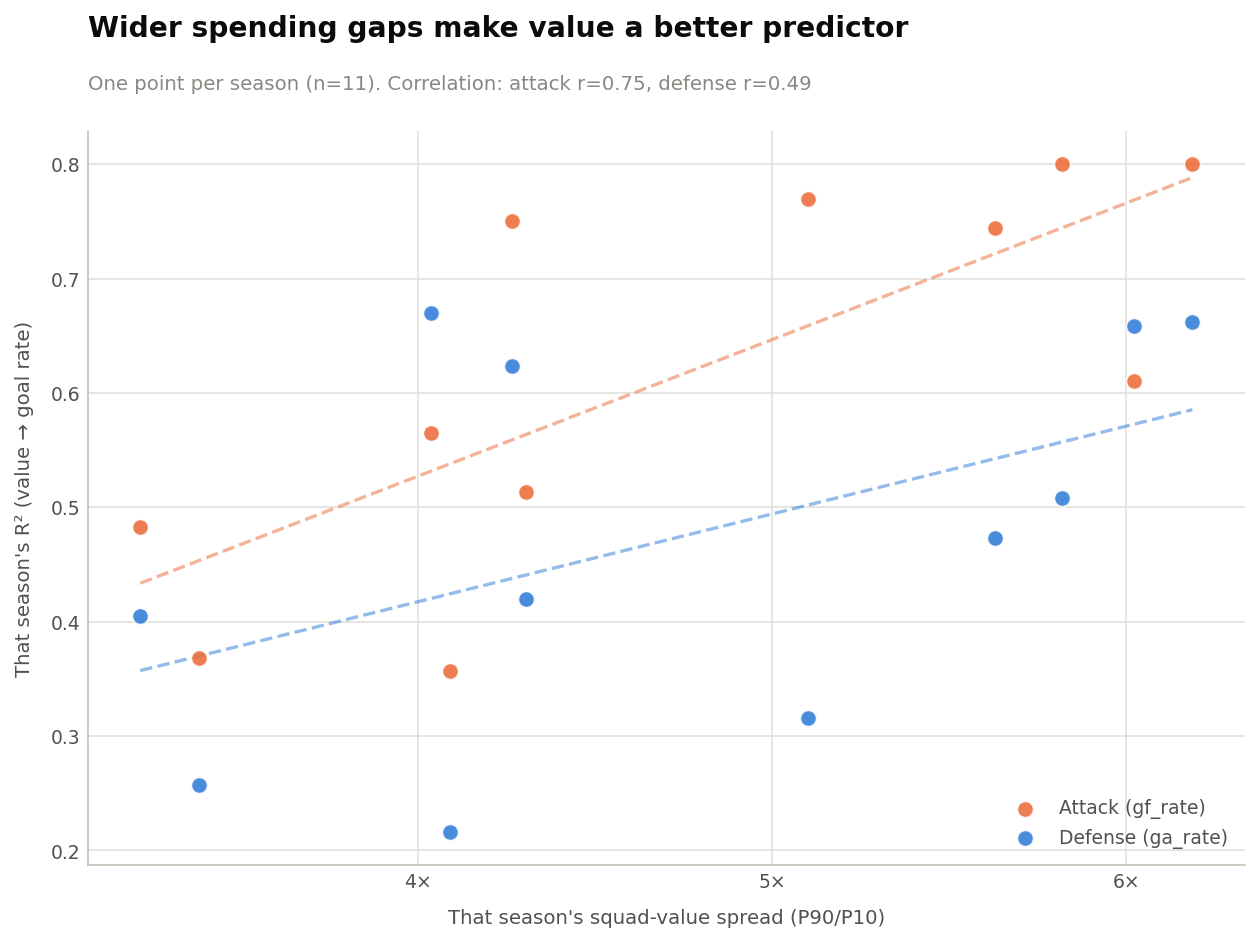

In [25]:
import statsmodels.api as sm

def _per_season_fit(panel, xcol, ycol):
    rows = []
    for season, g in panel.groupby('season'):
        X = sm.add_constant(g[xcol])
        m = sm.OLS(g[ycol], X).fit()
        rows.append({'season': season, 'r2': m.rsquared})
    return pd.DataFrame(rows).sort_values('season')

value_attack_by_season  = _per_season_fit(value_panel, 'log_value', 'gf_rate')
value_defense_by_season = _per_season_fit(value_panel, 'log_value', 'ga_rate')

g_v = values.groupby('season')['squad_value_2025_26_terms']
spread_by_season = (g_v.quantile(.9) / g_v.quantile(.1)).reindex(seasons_v).reset_index()
spread_by_season.columns = ['season', 'spread']

merged_a = value_attack_by_season.merge(spread_by_season, on='season')
merged_d = value_defense_by_season.merge(spread_by_season, on='season')

fig, ax = plt.subplots(figsize=(8.5, 6.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for df, color, label in [(merged_a, C_GOALS, 'Attack (gf_rate)'), (merged_d, C_XG, 'Defense (ga_rate)')]:
    ax.scatter(df['spread'], df['r2'], s=60, color=color, alpha=0.85,
               edgecolor='white', linewidth=0.8, zorder=3, label=label)
    coef = np.polyfit(df['spread'], df['r2'], 1)
    xs = np.linspace(df['spread'].min(), df['spread'].max(), 50)
    ax.plot(xs, np.polyval(coef, xs), color=color, linewidth=1.6, alpha=0.5, linestyle='--', zorder=2)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color(C_AXIS)
ax.spines['bottom'].set_color(C_AXIS)
ax.tick_params(length=0, colors=C_INK2, labelsize=9)
ax.grid(color=C_GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v:.0f}×'))

ax.set_xlabel("That season's squad-value spread (P90/P10)", fontsize=9.5, color=C_INK2, labelpad=8)
ax.set_ylabel("That season's R² (value → goal rate)", fontsize=9.5, color=C_INK2, labelpad=8)

r_a = np.corrcoef(merged_a['spread'], merged_a['r2'])[0, 1]
r_d = np.corrcoef(merged_d['spread'], merged_d['r2'])[0, 1]

ax.text(0, 1.12, 'Wider spending gaps make value a better predictor', transform=ax.transAxes,
        fontsize=13.5, fontweight='bold', color=C_INK, va='bottom', ha='left')
ax.text(0, 1.05, f'One point per season (n=11). Correlation: attack r={r_a:.2f}, defense r={r_d:.2f}',
        transform=ax.transAxes, fontsize=9.5, color=C_MUTED, va='bottom', ha='left')

ax.legend(loc='lower right', frameon=False, fontsize=9, labelcolor=C_INK2)

plt.tight_layout()
fig.subplots_adjust(top=0.84)
plt.savefig(OUT_DIR / 'spread_vs_r2.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

In [26]:
# Per-season significance check: the pooled n=220 regressions above all show
# p=0.000, but that's partly a function of sample size. Refit per season
# (n=20 each) to see whether the relationship holds up at realistic sample sizes.
def _per_season_sig(panel, xcol, ycol):
    rows = []
    for season, g in panel.groupby('season'):
        X = sm.add_constant(g[xcol])
        m = sm.OLS(g[ycol], X).fit()
        rows.append({'season': season, 'n': len(g), 'slope': m.params[xcol],
                     'p': m.pvalues[xcol], 'r2': m.rsquared})
    df = pd.DataFrame(rows).sort_values('season')
    df['sig'] = df['p'].apply(lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns')
    return df

for label, panel, xcol, ycol in [
    ('WAGE BILL -> gf_rate',  salary_panel, 'log_wage',  'gf_rate'),
    ('WAGE BILL -> ga_rate',  salary_panel, 'log_wage',  'ga_rate'),
    ('SQUAD VALUE -> gf_rate', value_panel, 'log_value', 'gf_rate'),
    ('SQUAD VALUE -> ga_rate', value_panel, 'log_value', 'ga_rate'),
]:
    df = _per_season_sig(panel, xcol, ycol)
    n_sig = (df['p'] < 0.05).sum()
    print(f'{label}  ({n_sig}/{len(df)} seasons significant at p<0.05)')
    print(df.round(4).to_string(index=False))
    print()

WAGE BILL -> gf_rate  (10/11 seasons significant at p<0.05)
   season  n  slope      p     r2 sig
2015-2016 20 0.4134 0.0119 0.3030   *
2016-2017 20 0.7172 0.0007 0.4780 ***
2017-2018 20 0.8239 0.0000 0.6163 ***
2018-2019 20 0.7785 0.0000 0.7174 ***
2019-2020 20 0.6384 0.0002 0.5510 ***
2020-2021 20 0.5293 0.0002 0.5542 ***
2021-2022 20 0.6451 0.0001 0.5809 ***
2022-2023 20 0.3534 0.0975 0.1451  ns
2023-2024 20 0.6018 0.0001 0.5689 ***
2024-2025 20 0.3949 0.0212 0.2616   *
2025-2026 20 0.5077 0.0002 0.5559 ***

WAGE BILL -> ga_rate  (11/11 seasons significant at p<0.05)
   season  n   slope      p     r2 sig
2015-2016 20 -0.3566 0.0167 0.2788   *
2016-2017 20 -0.5672 0.0010 0.4597  **
2017-2018 20 -0.3203 0.0206 0.2635   *
2018-2019 20 -0.5602 0.0006 0.4888 ***
2019-2020 20 -0.2533 0.0381 0.2177   *
2020-2021 20 -0.3282 0.0008 0.4709 ***
2021-2022 20 -0.4271 0.0047 0.3660  **
2022-2023 20 -0.3188 0.0262 0.2458   *
2023-2024 20 -0.5769 0.0001 0.5982 ***
2024-2025 20 -0.4256 0.0099 0.316